# Import Required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk

from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    SimpleRNN,
    LSTM,
    Dense,
    Dropout
)

from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

#Download NLTK Resources

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

# Load Dataset

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/AI ML Year 3 /FinalCoursework/Part3/Hotel_Reviews.csv')

#Understand Dataset

In [ ]:
df.head()

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20491 entries, 0 to 20490
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Review  20491 non-null  object
 1   Rating  20491 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 320.3+ KB


In [ ]:
df.isnull().sum()

,0
Review,0
Rating,0


#Selecting Required Columns

In [ ]:
df.columns

Index(['Review', 'Rating'], dtype='object')

In [ ]:
df = df[['Review', 'Rating']]

In [ ]:
df.head()

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


#Class Distribution

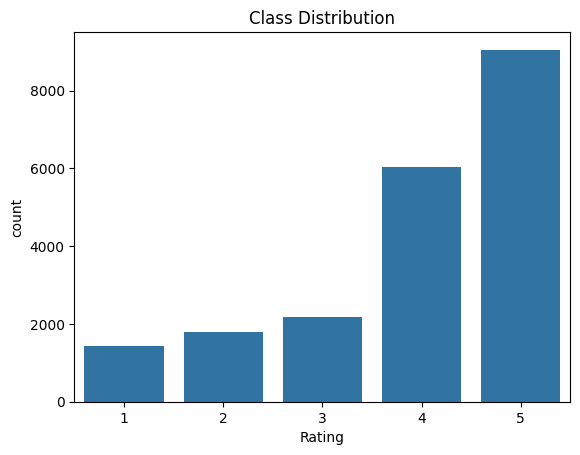

In [ ]:
sns.countplot(x=df['Rating'])
plt.title("Class Distribution")
plt.show()

# Text Preprocessing

In [ ]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

Initializing

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

Cleaning Function

In [ ]:
def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"@\w+", "", text)

    text = re.sub(r"#\w+", "", text)

    text = re.sub(r"[^a-zA-Z\s]", "", text)

    words = text.split()

    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

Apply Cleaning

In [ ]:
df['Cleaned_Review'] = df['Review'].apply(clean_text)

#Visualizing Cleaned Data

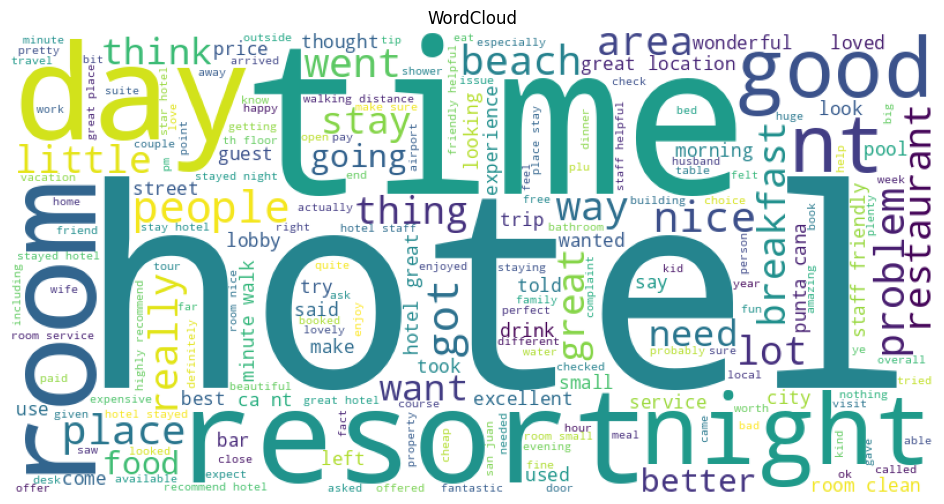

In [ ]:
all_words = " ".join(df['Cleaned_Review'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(all_words)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis('off')
plt.title("WordCloud")
plt.show()

Train & Test Splitting

In [ ]:
X = df['Cleaned_Review']
y = df['Rating']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Tokenization

In [ ]:
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)

Convert to Sequences

In [ ]:
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

Padding

In [ ]:
lengths = [len(seq) for seq in X_train_seq]

max_length = int(np.percentile(lengths, 95))

print(max_length)

245


In [ ]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding='post'
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding='post'
)

# Building RNN Model

In [ ]:
vocab_size = 10000

In [ ]:
rnn_model = Sequential()

rnn_model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_length
    )
)

rnn_model.add(SimpleRNN(64))

rnn_model.add(Dense(32, activation='relu'))

rnn_model.add(Dense(6, activation='softmax'))

Compile RNN

In [ ]:
rnn_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

Early Stopping

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

Train RNN

In [ ]:
import time

start_time = time.time()

history_rnn = rnn_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

rnn_training_time = time.time() - start_time

print("RNN Training Time:", rnn_training_time, "seconds")

Epoch 1/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 45s 109ms/step - accuracy: 0.4389 - loss: 1.3715 - val_accuracy: 0.4431 - val_loss: 1.3598
Epoch 2/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 40s 97ms/step - accuracy: 0.4422 - loss: 1.3675 - val_accuracy: 0.4532 - val_loss: 1.3563
Epoch 3/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 38s 93ms/step - accuracy: 0.4428 - loss: 1.3653 - val_accuracy: 0.4416 - val_loss: 1.3570
RNN Training Time: 125.80305051803589 seconds


Plotting Accuracy & Loss

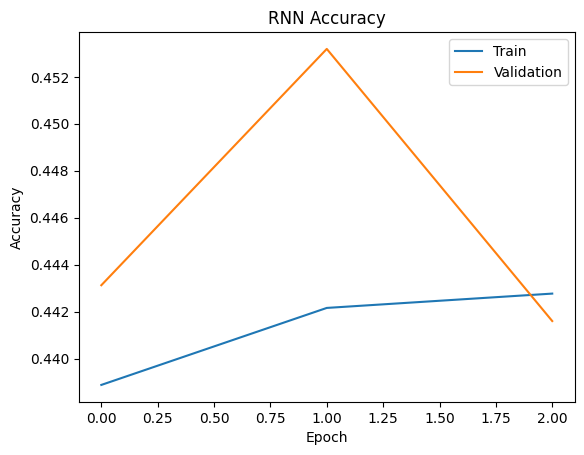

In [ ]:
plt.plot(history_rnn.history['accuracy'])
plt.plot(history_rnn.history['val_accuracy'])

plt.title('RNN Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train','Validation'])

plt.show()

Loss Graph

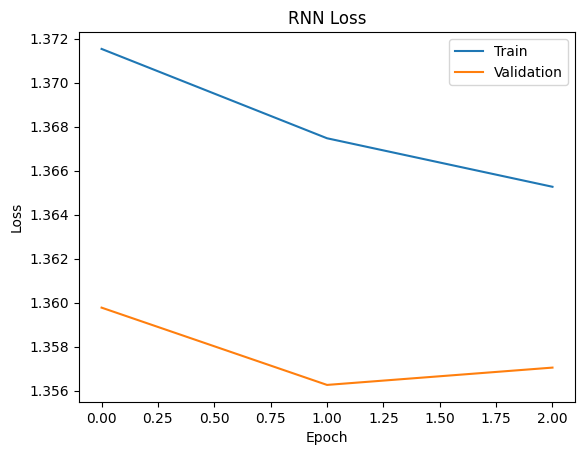

In [ ]:
plt.plot(history_rnn.history['loss'])
plt.plot(history_rnn.history['val_loss'])

plt.title('RNN Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train','Validation'])

plt.show()

Evaluate RNN

In [ ]:
rnn_predictions = rnn_model.predict(X_test_pad)

rnn_pred_classes = np.argmax(rnn_predictions, axis=1)

129/129 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step


Metrics

In [ ]:
print("Accuracy:",
      accuracy_score(y_test, rnn_pred_classes))

print("Precision:",
      precision_score(y_test, rnn_pred_classes, average='weighted'))

print("Recall:",
      recall_score(y_test, rnn_pred_classes, average='weighted'))

print("F1 Score:",
      f1_score(y_test, rnn_pred_classes, average='weighted'))

Accuracy: 0.4310807514027812
Precision: 0.2688257356814837
Recall: 0.4310807514027812
F1 Score: 0.2766557161735185


Classification Report

In [ ]:
print(classification_report(
    y_test,
    rnn_pred_classes
))

              precision    recall  f1-score   support

           1       0.00      0.00      0.00       292
           2       0.00      0.00      0.00       333
           3       0.00      0.00      0.00       432
           4       0.26      0.02      0.05      1252
           5       0.44      0.97      0.60      1790

    accuracy                           0.43      4099
   macro avg       0.14      0.20      0.13      4099
weighted avg       0.27      0.43      0.28      4099



Confusion Matrix

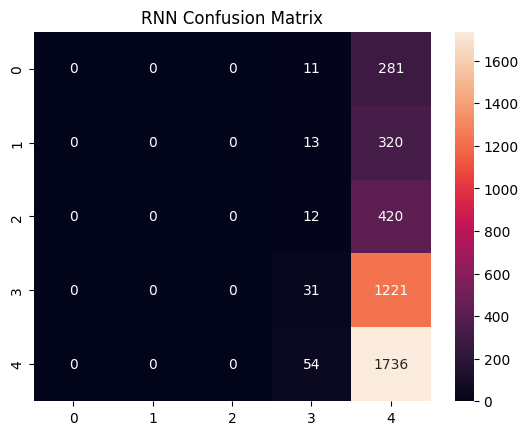

In [ ]:
cm = confusion_matrix(y_test, rnn_pred_classes)

sns.heatmap(cm, annot=True, fmt='d')

plt.title("RNN Confusion Matrix")

plt.show()

#Build LSTM Model

In [ ]:
# Build LSTM model with trainable embedding layer

lstm_model = Sequential()

lstm_model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=128,
        input_length=max_length
    )
)

lstm_model.add(LSTM(64))

lstm_model.add(Dense(32, activation='relu'))

lstm_model.add(Dense(6, activation='softmax'))

Compile LSTM Model

In [ ]:
lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

LSTM Model Summary

In [ ]:
lstm_model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Train LSTM Model

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
import time

In [ ]:
start_time = time.time()

history_lstm = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

lstm_training_time = time.time() - start_time

print("LSTM Training Time:", lstm_training_time, "seconds")

Epoch 1/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 77s 188ms/step - accuracy: 0.4521 - loss: 1.3456 - val_accuracy: 0.4559 - val_loss: 1.3461
Epoch 2/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 75s 183ms/step - accuracy: 0.4609 - loss: 1.3270 - val_accuracy: 0.4520 - val_loss: 1.3677
Epoch 3/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 83s 185ms/step - accuracy: 0.4687 - loss: 1.3076 - val_accuracy: 0.4541 - val_loss: 1.3811
Epoch 4/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 74s 180ms/step - accuracy: 0.4711 - loss: 1.2969 - val_accuracy: 0.4553 - val_loss: 1.3975
LSTM Training Time: 317.1305727958679 seconds


Plot LSTM Accuracy

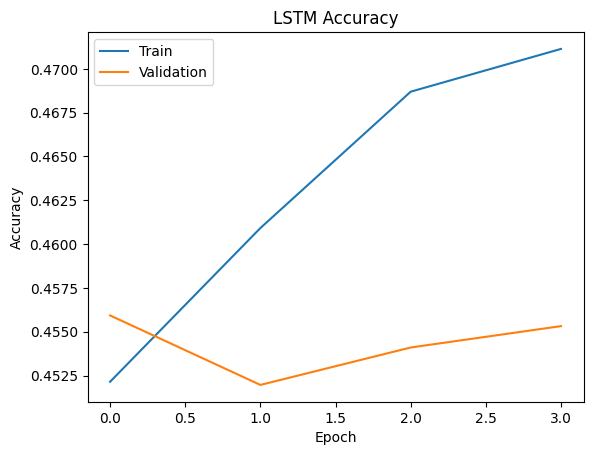

In [ ]:
plt.plot(history_lstm.history['accuracy'])
plt.plot(history_lstm.history['val_accuracy'])

plt.title('LSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

Plot LSTM Loss

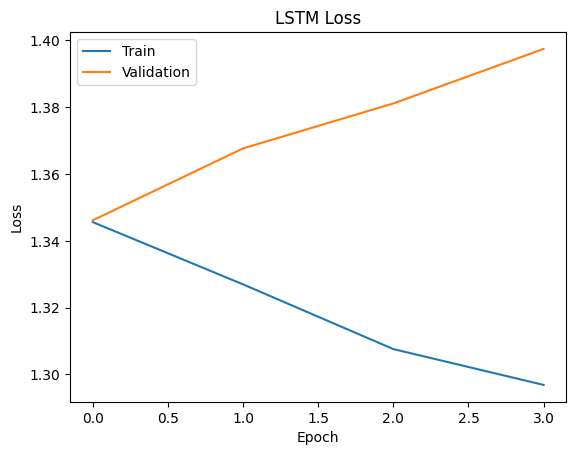

In [ ]:
plt.plot(history_lstm.history['loss'])
plt.plot(history_lstm.history['val_loss'])

plt.title('LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()

Evaluate LSTM

In [ ]:
lstm_predictions = lstm_model.predict(X_test_pad)

lstm_pred_classes = np.argmax(lstm_predictions, axis=1)

129/129 ━━━━━━━━━━━━━━━━━━━━ 6s 44ms/step


LSTM Metrics

In [ ]:
lstm_accuracy = accuracy_score(y_test, lstm_pred_classes)
lstm_precision = precision_score(y_test, lstm_pred_classes, average='weighted', zero_division=0)
lstm_recall = recall_score(y_test, lstm_pred_classes, average='weighted', zero_division=0)
lstm_f1 = f1_score(y_test, lstm_pred_classes, average='weighted', zero_division=0)

print("LSTM Accuracy:", lstm_accuracy)
print("LSTM Precision:", lstm_precision)
print("LSTM Recall:", lstm_recall)
print("LSTM F1 Score:", lstm_f1)

LSTM Accuracy: 0.4379116857770188
LSTM Precision: 0.3315532158498528
LSTM Recall: 0.4379116857770188
LSTM F1 Score: 0.28721053213457814


LSTM Classification Report

In [ ]:
print("LSTM Classification Report:")
print(classification_report(
    y_test,
    lstm_pred_classes,
    zero_division=0
))

LSTM Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00       292
           2       0.22      0.02      0.03       333
           3       0.07      0.00      0.00       432
           4       0.37      0.03      0.06      1252
           5       0.44      0.98      0.61      1790

    accuracy                           0.44      4099
   macro avg       0.22      0.21      0.14      4099
weighted avg       0.33      0.44      0.29      4099



LSTM Confusion Matrix

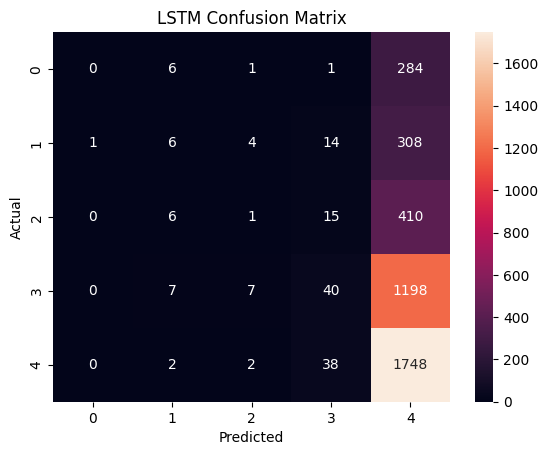

In [ ]:
lstm_cm = confusion_matrix(y_test, lstm_pred_classes)

sns.heatmap(lstm_cm, annot=True, fmt='d')

plt.title("LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#Model 3: LSTM with Pretrained Word2Vec / GloVe Embeddings

In [ ]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 28.1 MB/s eta 0:00:00


In [ ]:
import gensim.downloader as api

Loading Pretrained GloVe Embedding

In [ ]:
embedding_model = api.load('glove-wiki-gigaword-50')

[==================================================] 100.0% 66.0/66.0MB downloaded


Creating Embedding Matrix

In [ ]:
embedding_dim = 50

word_index = tokenizer.word_index

embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in word_index.items():
    if i < vocab_size:
        if word in embedding_model:
            embedding_vector = embedding_model[word]
            embedding_matrix[i] = embedding_vector

Build LSTM Model with Pretrained Embedding

In [ ]:
word2vec_lstm_model = Sequential()

word2vec_lstm_model.add(
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_length,
        trainable=False
    )
)

word2vec_lstm_model.add(LSTM(64))

word2vec_lstm_model.add(Dense(32, activation='relu'))

word2vec_lstm_model.add(Dense(6, activation='softmax'))

Compile Word2Vec-LSTM Model

In [ ]:
word2vec_lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

Model Summary

In [ ]:
word2vec_lstm_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,000 (1.91 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 500,000 (1.91 MB)

Train Word2Vec-LSTM Model

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
start_time = time.time()

history_word2vec_lstm = word2vec_lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

word2vec_lstm_training_time = time.time() - start_time

print("Word2Vec-LSTM Training Time:", word2vec_lstm_training_time, "seconds")

Epoch 1/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 48s 117ms/step - accuracy: 0.4451 - loss: 1.3540 - val_accuracy: 0.4550 - val_loss: 1.3456
Epoch 2/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 84s 123ms/step - accuracy: 0.4477 - loss: 1.3517 - val_accuracy: 0.4562 - val_loss: 1.3511
Epoch 3/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 82s 123ms/step - accuracy: 0.4471 - loss: 1.3463 - val_accuracy: 0.4526 - val_loss: 1.3512
Epoch 4/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 48s 117ms/step - accuracy: 0.4505 - loss: 1.3444 - val_accuracy: 0.4559 - val_loss: 1.3418
Epoch 5/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 82s 117ms/step - accuracy: 0.4518 - loss: 1.3368 - val_accuracy: 0.4575 - val_loss: 1.3390
Epoch 6/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 51s 124ms/step - accuracy: 0.4579 - loss: 1.3265 - val_accuracy: 0.4572 - val_loss: 1.3454
Epoch 7/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 79s 117ms/step - accuracy: 0.4618 - loss: 1.3131 - val_accuracy: 0.4559 - val_loss: 1.3564
Epoch 8/10
410/410 ━━━━━━━━━━━━━━━━━━━━ 51s 125ms/step - accuracy: 0.4674 - loss: 1

Plot Word2Vec-LSTM Accuracy

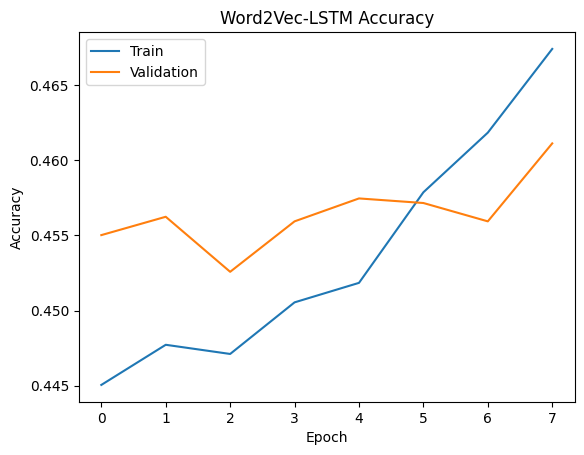

In [ ]:
plt.plot(history_word2vec_lstm.history['accuracy'])
plt.plot(history_word2vec_lstm.history['val_accuracy'])

plt.title('Word2Vec-LSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

Plot Word2Vec-LSTM Loss

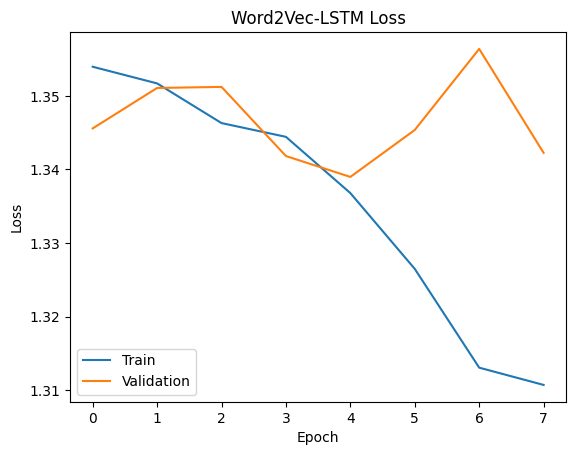

In [ ]:
plt.plot(history_word2vec_lstm.history['loss'])
plt.plot(history_word2vec_lstm.history['val_loss'])

plt.title('Word2Vec-LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Train', 'Validation'])

plt.show()

Evaluate Word2Vec-LSTM

In [ ]:
word2vec_predictions = word2vec_lstm_model.predict(X_test_pad)

word2vec_pred_classes = np.argmax(word2vec_predictions, axis=1)

129/129 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step


Word2Vec-LSTM Metrics

In [ ]:
word2vec_accuracy = accuracy_score(y_test, word2vec_pred_classes)
word2vec_precision = precision_score(y_test, word2vec_pred_classes, average='weighted', zero_division=0)
word2vec_recall = recall_score(y_test, word2vec_pred_classes, average='weighted', zero_division=0)
word2vec_f1 = f1_score(y_test, word2vec_pred_classes, average='weighted', zero_division=0)

print("Word2Vec-LSTM Accuracy:", word2vec_accuracy)
print("Word2Vec-LSTM Precision:", word2vec_precision)
print("Word2Vec-LSTM Recall:", word2vec_recall)
print("Word2Vec-LSTM F1 Score:", word2vec_f1)

Word2Vec-LSTM Accuracy: 0.44010734325445233
Word2Vec-LSTM Precision: 0.37859574581510697
Word2Vec-LSTM Recall: 0.44010734325445233
Word2Vec-LSTM F1 Score: 0.29985398574768624


Word2Vec-LSTM Classification Report

In [ ]:
print("Word2Vec-LSTM Classification Report:")
print(classification_report(
    y_test,
    word2vec_pred_classes,
    zero_division=0
))

Word2Vec-LSTM Classification Report:
              precision    recall  f1-score   support

           1       0.34      0.17      0.22       292
           2       0.38      0.01      0.02       333
           3       0.16      0.01      0.03       432
           4       0.36      0.02      0.04      1252
           5       0.45      0.96      0.61      1790

    accuracy                           0.44      4099
   macro avg       0.34      0.23      0.18      4099
weighted avg       0.38      0.44      0.30      4099



Word2Vec-LSTM Confusion Matrix

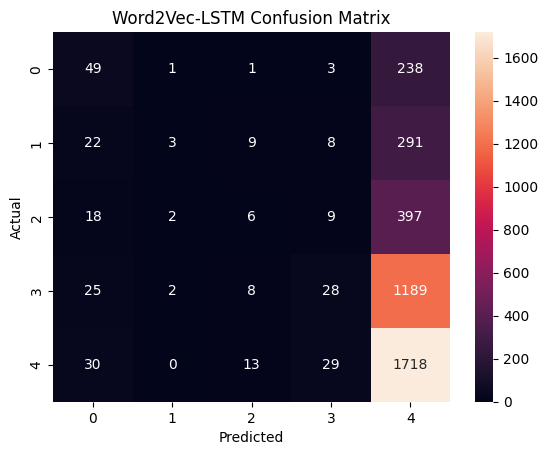

In [ ]:
word2vec_cm = confusion_matrix(y_test, word2vec_pred_classes)

sns.heatmap(word2vec_cm, annot=True, fmt='d')

plt.title("Word2Vec-LSTM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

#Storing Model Results

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Simple RNN",
        "LSTM",
        "Word2Vec-LSTM"
    ],
    "Accuracy": [
        accuracy_score(y_test, rnn_pred_classes),
        lstm_accuracy,
        word2vec_accuracy
    ],
    "Precision": [
        precision_score(y_test, rnn_pred_classes, average='weighted', zero_division=0),
        lstm_precision,
        word2vec_precision
    ],
    "Recall": [
        recall_score(y_test, rnn_pred_classes, average='weighted', zero_division=0),
        lstm_recall,
        word2vec_recall
    ],
    "F1-score": [
        f1_score(y_test, rnn_pred_classes, average='weighted', zero_division=0),
        lstm_f1,
        word2vec_f1
    ],
    "Training Time (seconds)": [
        rnn_training_time,
        lstm_training_time,
        word2vec_lstm_training_time
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-score,Training Time (seconds)
0,Simple RNN,0.431081,0.268826,0.431081,0.276656,125.803051
1,LSTM,0.437912,0.331553,0.437912,0.287211,317.130573
2,Word2Vec-LSTM,0.440107,0.378596,0.440107,0.299854,556.459354


Accuracy Comparison Graph

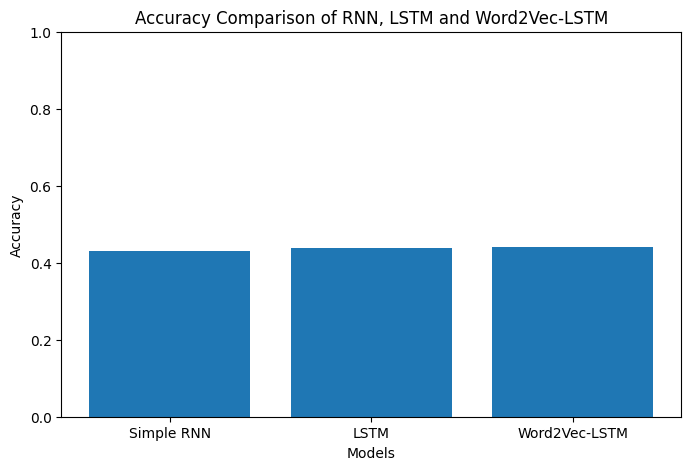

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(results["Model"], results["Accuracy"])

plt.title("Accuracy Comparison of RNN, LSTM and Word2Vec-LSTM")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.show()

Precision Comparison Graph

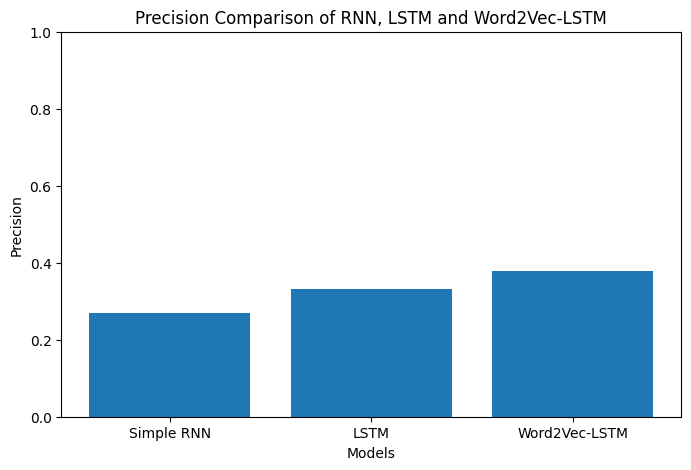

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(results["Model"], results["Precision"])

plt.title("Precision Comparison of RNN, LSTM and Word2Vec-LSTM")
plt.xlabel("Models")
plt.ylabel("Precision")
plt.ylim(0, 1)

plt.show()

F1-score Comparison Graph

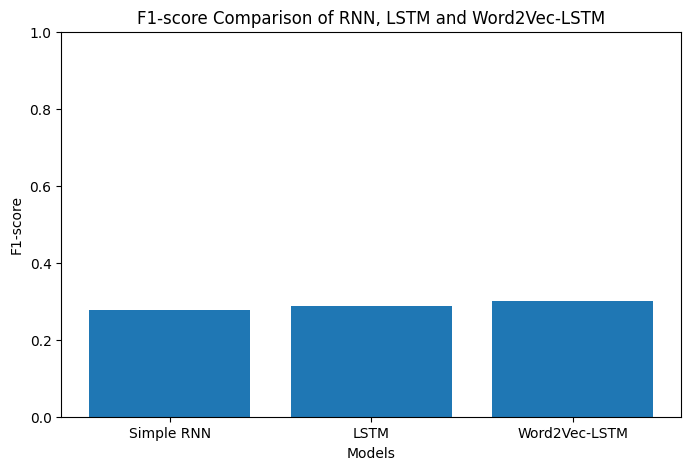

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(results["Model"], results["F1-score"])

plt.title("F1-score Comparison of RNN, LSTM and Word2Vec-LSTM")
plt.xlabel("Models")
plt.ylabel("F1-score")
plt.ylim(0, 1)

plt.show()

Training Time Comparison Graph

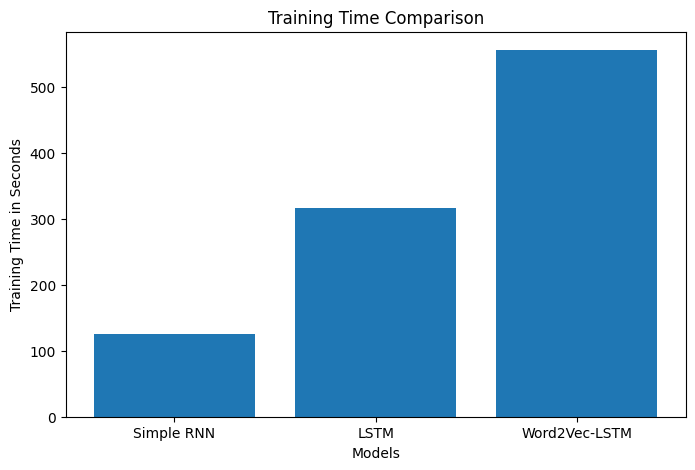

In [ ]:
plt.figure(figsize=(8, 5))
plt.bar(results["Model"], results["Training Time (seconds)"])

plt.title("Training Time Comparison")
plt.xlabel("Models")
plt.ylabel("Training Time in Seconds")

plt.show()

#Error Analysis

In [ ]:
# Error Analysis for Word2Vec-LSTM Model

error_df = pd.DataFrame({
    "Review": X_test.values,
    "Actual Rating": y_test.values,
    "Predicted Rating": word2vec_pred_classes
})

wrong_predictions = error_df[
    error_df["Actual Rating"] != error_df["Predicted Rating"]
]

wrong_predictions.head(3)

,Review,Actual Rating,Predicted Rating
0,recommend hotel reviewer actually stay hotel g...,1,5
2,ok hotel good location stayed night way beijin...,3,5
3,great service nice pool ok beach lovely ground...,4,3


In [ ]:
for i in range(min(3, len(wrong_predictions))):
    print("Review:")
    print(wrong_predictions.iloc[i]["Review"])
    print("Actual Rating:", wrong_predictions.iloc[i]["Actual Rating"])
    print("Predicted Rating:", wrong_predictions.iloc[i]["Predicted Rating"])
    print("-" * 80)

Review:
recommend hotel reviewer actually stay hotel good thing hotel location really close leidseplein shared facility filthy got look toilet floor cleaned month facility cleaned day got disgusting staff rude complained left night early refused refund night recommend hotel
Actual Rating: 1
Predicted Rating: 5
--------------------------------------------------------------------------------
Review:
ok hotel good location stayed night way beijing rawa island hotel service room ok location great shopping restaurant probably stay opinion nice star hotel
Actual Rating: 3
Predicted Rating: 5
--------------------------------------------------------------------------------
Review:
great service nice pool ok beach lovely ground small room stayed day night st th quick cab ride hotel line checkin requested king bed guaranteed offered double b club level floor wasnt thrilled went ground hotel beautiful issue poster close airport nonissue inside hotel heard plane taking outside hotel heard thrust e

#GUI for Real-Time Prediction/


In [ ]:
!pip install gradio

Create Prediction Function

In [ ]:
def predict_review(review):

    cleaned = clean_text(review)

    sequence = tokenizer.texts_to_sequences([cleaned])

    padded = pad_sequences(
        sequence,
        maxlen=max_length,
        padding='post'
    )

    prediction = word2vec_lstm_model.predict(padded)

    predicted_class = np.argmax(prediction, axis=1)[0] + 1

    return f"Predicted Rating: {predicted_class}"

Build Gradio Interface

In [ ]:
import gradio as gr

interface = gr.Interface(
    fn=predict_review,
    inputs=gr.Textbox(lines=5, placeholder="Enter hotel review here..."),
    outputs="text",
    title="Hotel Review Rating Prediction",
    description="Predict hotel review ratings using Word2Vec-LSTM model"
)

Launch GUI

In [ ]:
interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a98936f7865c909133.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


#Conclusion and Future Work

**Conclusion**

This project focused on hotel review rating prediction using deep learning and natural language processing techniques. Three different models were implemented and compared: SimpleRNN, LSTM, and Word2Vec-LSTM. Various preprocessing techniques such as text cleaning, stopword removal, tokenization, and sequence padding were applied before training the models.


The experimental results showed that the LSTM model slightly outperformed the SimpleRNN baseline model due to its improved ability to capture sequential dependencies in textual data. The Word2Vec-LSTM model demonstrated improved minority-class recognition and semantic understanding compared to the baseline models, although overall accuracy remained limited due to dataset imbalance and overlapping review sentiments.


The project also highlighted the importance of evaluation metrics such as precision, recall, and F1-score, since accuracy alone did not fully represent model performance. In addition, a Gradio-based GUI was successfully developed for real-time hotel review rating prediction.

**Future Work**

Future improvements could include:

* using larger and more balanced datasets,
* applying transformer-based models such as BERT,
* using trainable pretrained embeddings,
* performing hyperparameter tuning,
* improving minority-class prediction,
* and deploying the application as a web-based sentiment analysis system.

